# Introduction 
Hello people! Welcome to my kernel. In this kernel, I will apply some Unsupervised Learning Algorithms over Breast Canser dataset. In this kernel, I am going to use two different clustering algorithms:

* K-Means Clustering
* Hierarchial (Agglomerative) Clustering

Therefore, I am going to use SKLearn library. Let's take a look at our schedule.

# Schedule
1. Importing Libraries and Data
1. Having Idea About Data
1. Preprocessing 
1. Unsupervised Learning
    * K-Means Clustering
    * Hierarchial (Agglomerative) Clustering
1. Comparing Labels
1. Conclusion


# Importing Libraries and Data

In this section I am going to import libraries and data that I will use.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import matplotlib.pyplot as plt
import seaborn as sns



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-cancer-wisconsin-data/data.csv


In [2]:
data = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')

# Having Idea About Data

In this section I am going to diagnose data, because I can not prepare my dataset for Machine Learning without any idea. In order to diagnose I am going to use head(),tail() and info() functions.

In [3]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


* There are 33 Features in our dataset

In [4]:
data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


* There are 569 rows in our dataset

In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

There are not NaN values in our dataset. I am going to drop these features:

* Id 
* Unnamed: 32
* Diagnosis (Because it is our label)

# Preprocessing

In this section I am going to prepare data for machine learning. Therefore I am going to start with dropping the features that I have decided in previous section

In [6]:
data2 = data.copy() 
data.drop(["id","Unnamed: 32","diagnosis"],axis=1,inplace=True)


In [7]:
data.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Unsupervised Learning
In this section I am going to apply clustering algorithms to our dataset. I am going to start with K-Means Algorithm

## K-Means Clustering

In this sub-section I am going to cluster our dataset using K-Means Algorithm. In order to do this I am going to use SKLearn library. Let's do it!

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2) # I've chosen n_clusters=2 because there are two classes in our dataset.
kmeans_labels = kmeans.fit_predict(data)

Our clustering model is ready. I've saved clustering labels in a variable. In the future I am going to add them into our dataset.

## Hierarchial (Agglomerative) Clustering

In this sub-section I am going to cluster our dataset using Hierarchial Clustering Algorithm. In order to do this I am going to use SKLearn library again

In [9]:
from sklearn.cluster import AgglomerativeClustering
hier = AgglomerativeClustering(n_clusters=2,affinity="euclidean",linkage="ward")
hier_labels = hier.fit_predict(data)

* Our labels are ready. We are ready to compare labels

# Comparing Labels
In this section I am going to compare labels. At the start of this section I am going to add K-Means Label and Hier Label features.

In [10]:
data2.drop(["Unnamed: 32","id"],axis=1,inplace=True)
data2["KMeansLabel"] = kmeans_labels
data2["HierLabel"] = hier_labels

In [11]:
data2.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,KMeansLabel,HierLabel
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,0
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,1


And now I am going to drop all columns except diagnosis and labels

In [12]:
data3 = data2.loc[:,["diagnosis","KMeansLabel","HierLabel"]]
data3

,diagnosis,KMeansLabel,HierLabel
0,M,1,1
1,M,1,1
2,M,1,1
3,M,0,0
4,M,1,1
...,...,...,...
564,M,1,1
565,M,1,1
566,M,0,0
567,M,1,1


In [13]:
print("Diagnosis = M and Cluster 0 Data Dots: ",len(data3[(data3["diagnosis"]=="M") & (data3.KMeansLabel==0) & (data3.HierLabel==0)]))
print("Diagnosis = M and Cluster 1 Data Dots:",len(data3[(data3["diagnosis"]=="M") & (data3.KMeansLabel==1) & (data3.HierLabel==1)]))


Diagnosis = M and Cluster 0 Data Dots:  82
Diagnosis = M and Cluster 1 Data Dots: 86


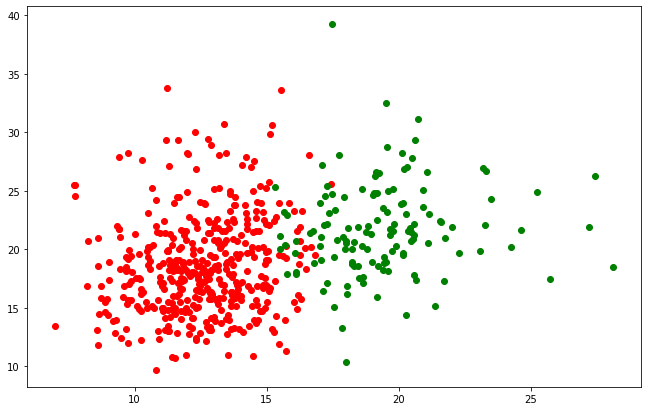

In [14]:
fig,ax = plt.subplots(figsize=(11,7))
plt.scatter(data2["radius_mean"][data2.KMeansLabel==0],data2["texture_mean"][data2.KMeansLabel==0],color="Red")
plt.scatter(data2["radius_mean"][data2.KMeansLabel==1],data2["texture_mean"][data2.KMeansLabel==1],color="Green")
plt.show()

## As you can see, There is not a relation between Cluster and Class
So we can say, clustering is not equals classification

# Conclusion

I am a beginner in machine learning so I might have mistakes in this kernel. Please tell me my mistakes. But If there are not any mistakes, if you upvote this kernel I would be glad.